### EMPC without Terminal Ingredients GRUENE AND PIRKELMANN

Copyright &copy; 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [2]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from params import EMPCParamsGruene
from systems import NonlinearSystem
from controllers import EMPC

In [4]:
# Fix random seed
np.random.seed(1)

##### Load parameters and create system

In [11]:
params = EMPCParamsGruene()
sys = NonlinearSystem(params.sys)

##### Initialize controller

In [12]:
ctrl = EMPC(sys, params.ctrl)

### Simulate System

In [16]:
x_0 = params.sim.x_0
x_0.shape
x[:,0,:] = x_0

In [17]:
# Setup simulation
num_steps = params.sim.num_steps
num_traj = params.sim.num_traj
x_0 = params.sim.x_0

# Allocate state and input trajectories
x = np.zeros((num_traj, num_steps+1, sys.n))
u = np.zeros((num_traj, num_steps, sys.m))

# Simulate closed-loop system
x[:,0,:] = x_0
for i in range(num_traj):
    for t in range(num_steps):
        sol_u, sol_x, error_msg = ctrl.solve(x[i,t,:], additional_parameters=t, verbose=False)
        if error_msg != None:
            raise Exception(error_msg)
        u[i,t,  :] = sol_u[0]
        x[i,t+1,:] = sol_x[1]   # x[i,t+1,:] = sys.step(x[i,t,:], u[i,t]).reshape(-1)

##### Plot result

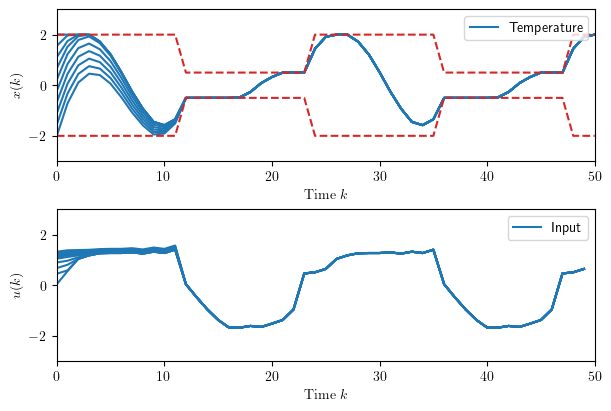

In [26]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
t = np.arange(num_steps+1)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(6, 4), layout='constrained')

# Plot trajectories
for i in range(num_traj):
    axs[0].plot(t, x[i,:,0], label='Temperature' if i == 0 else '_', color='tab:blue', linestyle='-')
    axs[1].plot(t[:-1], u[i,:,0], label='Input'  if i == 0 else '_', color='tab:blue', linestyle='-')

# Plot state constraints
axs[0].plot(t, [ 2 if k % 24 < 12 else  1/2 for k in t], label='_', color='tab:red', linestyle='--')
axs[0].plot(t, [-2 if k % 24 < 12 else -1/2 for k in t], label='_', color='tab:red', linestyle='--')

# Add labels
axs[0].set_xlabel(r'\rmfamily{Time} $k$')
axs[0].set_ylabel('$x(k)$')
axs[1].set_xlabel(r'\rmfamily{Time} $k$')
axs[1].set_ylabel('$u(k)$')

# Set limits
axs[0].set_xlim([0, t.max()])
axs[0].set_ylim([-3, 3])
axs[1].set_xlim([0, t.max()])
axs[1].set_ylim([-3, 3])

# Plot legend
axs[0].legend(loc='upper right')
axs[1].legend(loc='upper right')

# Export figure
# fig.savefig("figures/figure_gruene.svg")